## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torchaudio.functional as taf
from torchaudio.transforms import Spectrogram, AmplitudeToDB
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from kymatio.numpy import Scattering1D
from typing import Optional, Dict
import os
import warnings

plt.rcParams['font.family'] = 'serif'
warnings.filterwarnings('ignore')

In [2]:
class LogLinearFilterBank(nn.Module):
    def __init__(
        self,
        sample_rate: int = 16000,
        n_filter: int = 80,
        f_min: float = 0.0,
        f_max: Optional[float] = None,
        log_lf: bool = False,
        top_db: float = 80.0,
        speckwargs: Optional[Dict] = None,
    ) -> None:
        super(LogLinearFilterBank, self).__init__()
        self.sample_rate = sample_rate
        self.f_min = f_min
        self.f_max = f_max if f_max is not None else float(sample_rate // 2)
        self.n_filter = n_filter
        self.log_lf = log_lf
        self.amplitude_to_DB = AmplitudeToDB('power', top_db)
        speckwargs = speckwargs or {}
        if 'n_fft' not in speckwargs:
            speckwargs['n_fft'] = 512
        self.Spectrogram = Spectrogram(**speckwargs)
        n_freqs = (speckwargs['n_fft'] // 2) + 1
        filter_mat = taf.linear_fbanks(
            n_freqs=n_freqs, f_min=self.f_min, f_max=self.f_max,
            n_filter=self.n_filter, sample_rate=self.sample_rate,
        )
        self.register_buffer('filter_mat', filter_mat)

    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        specgram = self.Spectrogram(waveform)
        specgram = torch.matmul(specgram.transpose(-1, -2), self.filter_mat)
        specgram = specgram.transpose(-1, -2)
        if self.log_lf:
            return torch.log(specgram + 1e-6)
        else:
            return self.amplitude_to_DB(specgram)

## 3. Acoustic Feature Extraction

In [7]:
def get_features(file_path, label='Audio', target_duration=5.0):
    if not os.path.exists(file_path): return None
    y, sr = librosa.load(file_path, sr=16000)
    tl = int(sr * target_duration)
    y = y[-tl:] if len(y) > tl else np.pad(y, (0, tl-len(y)))
    waveform = torch.tensor(y, dtype=torch.float32).unsqueeze(0)
    n_fft, hop = 512, 160
    res = {}

    # Mel
    res['mel'] = librosa.amplitude_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop, n_mels=80), ref=np.max)

    # Linear
    ext = LogLinearFilterBank(sample_rate=sr, n_filter=80, f_min=0., f_max=8000.,
                               speckwargs={'n_fft':n_fft,'hop_length':hop,'power':2.0})
    with torch.no_grad():
        res['linear'] = ext(waveform).squeeze(0).numpy()

    # CQT
    try:
        res['cqt'] = librosa.amplitude_to_db(
            np.abs(librosa.cqt(y, sr=sr, hop_length=hop, n_bins=84)), ref=np.max)
    except: res['cqt'] = np.zeros((84,100))

    # WST
    T = y.shape[0]; J = 8
    if T < 2**J: J = int(np.floor(np.log2(T))) - 1
    try:
        sc = Scattering1D(J=J, shape=(T,), Q=10)
        Sx = sc(y); meta = sc.meta()
        o1 = Sx[meta['order']==1]; o2 = Sx[meta['order']==2]
        res['wst1'] = librosa.amplitude_to_db(o1 if o1.size else np.zeros((10,10)), ref=np.max)
        res['wst2'] = librosa.amplitude_to_db(o2 if o2.size else np.zeros((10,10)), ref=np.max)
    except Exception as e:
        print(f'WST err: {e}')
        res['wst1'] = res['wst2'] = np.zeros((20,100))
    return res

## 4. Load Real and Fake Audio

In [ ]:
real_path = '/xxuan-acoustic/source_tracing_dataset/M-AILABS/en_US/en_US/by_book/female/judy_bieber/dorothy_and_wizard_oz/wavs/dorothy_and_wizard_oz_01_f000028.wav'
fake_path = '/xxuan-acoustic/dataset/MLAAD_v8/MLAAD/fake/en/Qwen2.5-Omni/dorothy_and_wizard_oz_01_f000028.wav'

real_data = get_features(real_path, 'REAL')
fake_data = get_features(fake_path, 'FAKE')
assert real_data and fake_data, 'Feature extraction failed — check paths'
print('Done')

Done


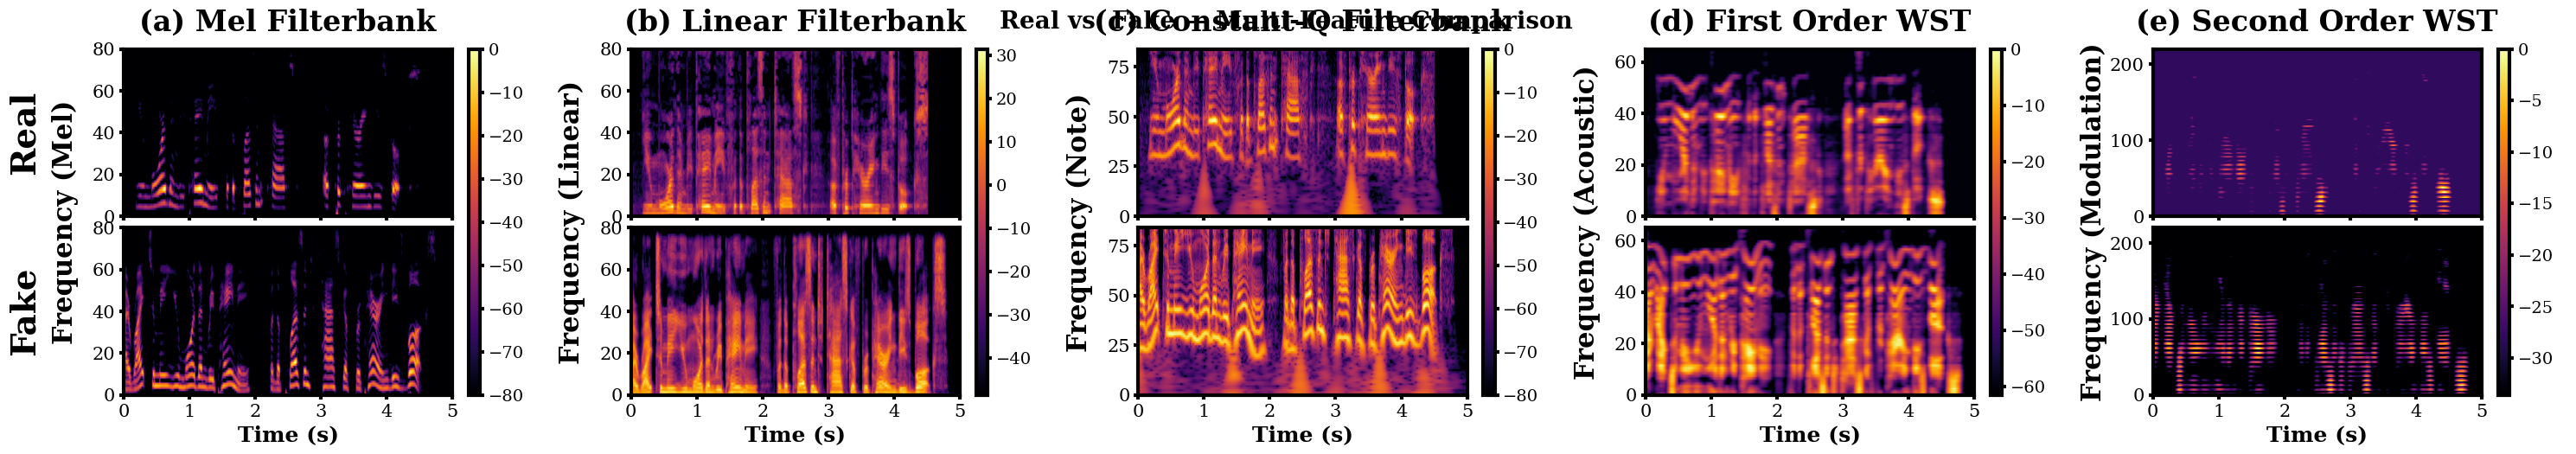

In [9]:
%matplotlib inline

cfg = [
    ('mel',    '(a) Mel Filterbank',        'inferno', 'Frequency (Mel)'),
    ('linear', '(b) Linear Filterbank',     'inferno', 'Frequency (Linear)'),
    ('cqt',    '(c) Constant-Q Filterbank', 'inferno', 'Frequency (Note)'),
    ('wst1',   '(d) First Order WST',       'inferno', 'Frequency (Acoustic)'),
    ('wst2',   '(e) Second Order WST',      'inferno', 'Frequency (Modulation)'),
]

limits = []
for key,*_ in cfg:
    gmax = max(np.max(real_data[key]), np.max(fake_data[key]))
    gmin = min(np.min(real_data[key]), np.min(fake_data[key]))
    if key in ('mel','linear','wst1','wst2'): gmin = max(gmin, gmax-80)
    limits.append((gmin, gmax))

fig = plt.figure(figsize=(32, 5))
gs  = gridspec.GridSpec(2, 5, figure=fig,
                        wspace=0.25, hspace=0.07,
                        left=0.08, right=0.96, top=0.92, bottom=0.12)

for ci, (key, title, cmap, ylabel) in enumerate(cfg):
    vmin, vmax = limits[ci]

    # ghost axis for centred y-label
    ag = fig.add_subplot(gs[:, ci], frameon=False)
    ag.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    ag.set_ylabel(ylabel, fontsize=22, fontweight='bold', labelpad=15)

    ax_r = fig.add_subplot(gs[0, ci])
    ax_f = fig.add_subplot(gs[1, ci])
    im_obj = None

    for ri, (ax, dat, lbl) in enumerate([(ax_r,real_data,'Real'),(ax_f,fake_data,'Fake')]):
        img = dat[key]
        ylim = 80 if key in ('mel','linear') else img.shape[0]
        im = ax.imshow(img, aspect='auto', origin='lower', cmap=cmap,
                       extent=[0,5,0,ylim], vmin=vmin, vmax=vmax)
        if ri == 1: im_obj = im
        for sp in ax.spines.values(): sp.set_linewidth(3.0)
        ax.tick_params(labelsize=15, width=3)
        if ri == 0:
            ax.set_title(title, fontsize=24, fontweight='bold', pad=15)
            ax.set_xticklabels([])
        else:
            ax.set_xlabel('Time (s)', fontsize=18, fontweight='bold')
        if ci == 0:
            ax.text(-0.30, 0.5, lbl, transform=ax.transAxes,
                    fontsize=28, fontweight='bold', rotation=90, va='center', ha='center')

    cb = fig.colorbar(im_obj, ax=[ax_r,ax_f], location='right', aspect=30, shrink=1.0, pad=0.04)
    cb.outline.set_linewidth(3.0)
    cb.ax.tick_params(labelsize=14, width=3)

plt.suptitle('Real vs. Fake — Multi-Feature Comparison', fontsize=20, fontweight='bold', y=1.01)
plt.show()

In [10]:
save_path = './spec_fig/comparison.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, dpi=600, format='pdf', bbox_inches='tight')
print(f'Saved -> {save_path}')

Saved -> ./spec_fig/comparison.pdf
